**Program No. 22.  >> Sentiment Analysis Visualization** 

**Objective:** To analyze sentiment from social media data.

**Tasks:**
- Implement sentiment analysis on live tweet data using Python libraries

**Outcome:** Students will apply NLP techniques for visualization.

**Step 1:** Install Required Library

In [1]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable
  Using cached textblob-0.19.0-py3-none-any.whl.metadata (4.4 kB)
Using cached textblob-0.19.0-py3-none-any.whl (624 kB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Step 2:** Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

**Step 3:** Create / Load Tweet Dataset

In [3]:
tweets = [
    "I love this new phone, the camera quality is amazing!",
    "This service is terrible, I am very disappointed.",
    "The weather is okay today.",
    "Absolutely fantastic experience, highly recommend it!",
    "Worst product ever, waste of money.",
    "The update is fine, nothing special.",
    "Customer support was very helpful and polite.",
    "I hate how slow this app is.",
    "Great performance and smooth interface.",
    "It works as expected."
]

df = pd.DataFrame({"Tweet": tweets})

**Step 4:** Perform Sentiment Analysis

In [4]:
def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Tweet"].apply(get_sentiment)

print(df)

                                               Tweet Sentiment
0  I love this new phone, the camera quality is a...  Positive
1  This service is terrible, I am very disappointed.  Negative
2                         The weather is okay today.  Positive
3  Absolutely fantastic experience, highly recomm...  Positive
4                Worst product ever, waste of money.  Negative
5               The update is fine, nothing special.  Positive
6      Customer support was very helpful and polite.  Positive
7                       I hate how slow this app is.  Negative
8            Great performance and smooth interface.  Positive
9                              It works as expected.  Negative


**Step 5:** Sentiment Distribution Visualization

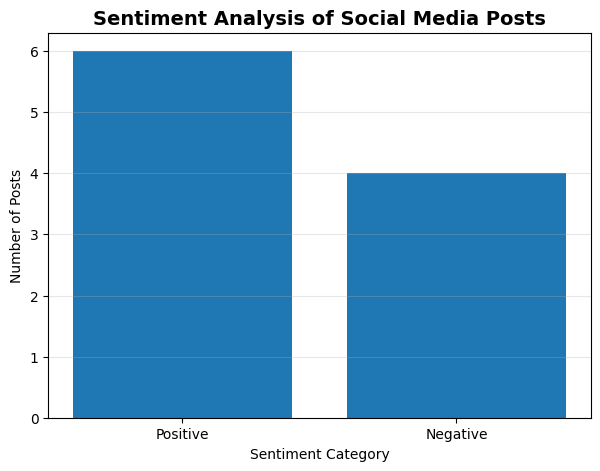

In [5]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Analysis of Social Media Posts",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Sentiment Category")
plt.ylabel("Number of Posts")

plt.grid(axis="y", alpha=0.3)
plt.show()

**Pie Chart View**

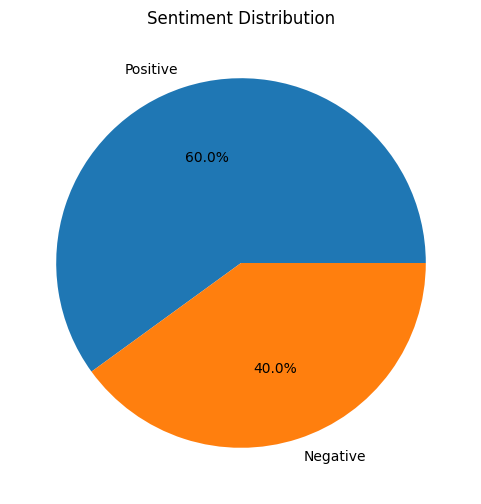

In [6]:
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct="%1.1f%%")

plt.title("Sentiment Distribution")
plt.show()

**Sentiment Analysis — Tweet Data (Dual Panel Visualization)**

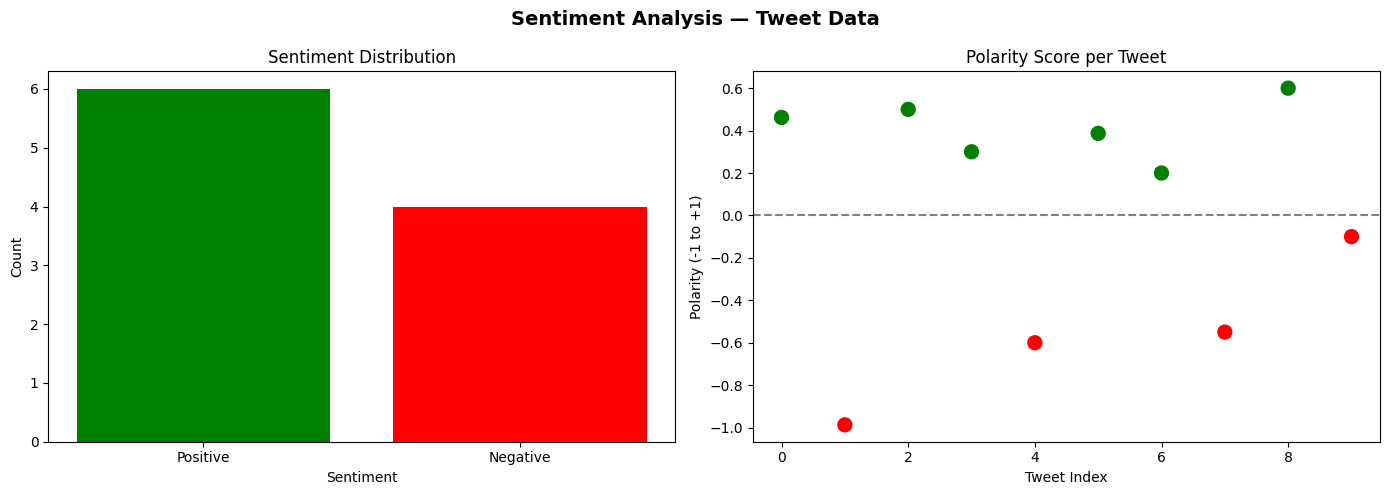

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from textblob import TextBlob

# If polarity column not created yet
if "Polarity" not in df.columns:
    df["Polarity"] = df["Tweet"].apply(lambda x: TextBlob(x).sentiment.polarity)

# If sentiment column not created yet
if "Sentiment" not in df.columns:
    def get_sentiment(p):
        if p > 0:
            return "Positive"
        elif p < 0:
            return "Negative"
        else:
            return "Neutral"
    df["Sentiment"] = df["Polarity"].apply(get_sentiment)

# Create figure
fig, axs = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("Sentiment Analysis — Tweet Data", fontsize=14, fontweight="bold")

# --------------------------------------------------
# 1️⃣ Sentiment Distribution (Bar Chart)
# --------------------------------------------------
sentiment_counts = df["Sentiment"].value_counts()

colors = sentiment_counts.index.map({
    "Positive": "green",
    "Negative": "red",
    "Neutral": "gray"
})

axs[0].bar(sentiment_counts.index,
           sentiment_counts.values,
           color=colors)

axs[0].set_title("Sentiment Distribution")
axs[0].set_xlabel("Sentiment")
axs[0].set_ylabel("Count")

# --------------------------------------------------
# 2️⃣ Polarity Score per Tweet (Scatter Plot)
# --------------------------------------------------
colors_scatter = df["Polarity"].apply(lambda x: "green" if x>0 else ("red" if x<0 else "gray"))

axs[1].scatter(range(len(df)),
               df["Polarity"],
               c=colors_scatter,
               s=100)

axs[1].axhline(0, linestyle="--", color="gray")

axs[1].set_title("Polarity Score per Tweet")
axs[1].set_xlabel("Tweet Index")
axs[1].set_ylabel("Polarity (-1 to +1)")

plt.tight_layout()
plt.show()

**If majority is:**
- **Positive** → Brand reputation strong
- **Negative** → Need improvement
- **Neutral** → Informational content